### Niezbędne biblioteki

In [1]:
!pip install pandas
!pip install shap
!pip install xgboost scikit-learn pandas
!pip install lime
!pip install ipython==7.23.1
!pip install ucimlrepo


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Definicje funkcji

In [6]:
#------------------------------------------------- LIME ------------------------------------------------
from lime.lime_tabular import LimeTabularExplainer 

def return_lime_weights(exp, prediction_class_number, n_features): 
    exp_weight = np.zeros(n_features)
    for feature_id, weight in exp.as_map()[prediction_class_number]:
        exp_weight[feature_id] = weight

    return exp_weight 

def lime(model, X_train, class_names, sample_id): 
    feature_names = list(X_train.columns) 
    explainer_lime = LimeTabularExplainer( 
        X_train.values, feature_names = feature_names, class_names = class_names, mode = 'classification' 
    ) 
    
    exp_lime = explainer_lime.explain_instance( 
        X_train.iloc[sample_id].values, model.predict_proba, num_features = len(X_train.columns), top_labels = len(class_names) 
    ) 
    
    for label in exp_lime.top_labels: 
        exp_lime.as_pyplot_figure(label = label) 
        plt.show() 
        
    print("\n\n") 
    exp_lime.show_in_notebook() 
    print("\n\n") 

    overall_weights = []
    for i in range(0, len(class_names)):
        weights = []
        for _, x in X_train.iterrows(): 
            predict_fn = lambda x: model.predict_proba(pd.DataFrame(x, columns=X_train.columns))
            
            exp = explainer_lime.explain_instance(
                x.values, predict_fn, num_features = len(X_train.columns), labels = list(range(len(class_names)))
            )
            exp_weight = return_lime_weights(exp, i, len(X_train.columns)) 
            weights.append(exp_weight)
            
        lime_weights = pd.DataFrame(data = weights, columns = X_train.columns) 
        
        abs_mean = lime_weights.abs().mean(axis=0).reset_index()
        abs_mean.columns = ['feature', 'abs_mean'] 
        abs_mean = abs_mean.sort_values('abs_mean') 
        overall_weights.append(abs_mean)

    print(np.shape(overall_weights))
    lime_matrix = pd.DataFrame({
        f"{i}": tab.set_index('feature')['abs_mean'] for i, tab in enumerate(overall_weights)
    })
    
    plt.figure()
    fig, ax = plt.subplots(1, 1, figsize = (20, 10))
    lime_matrix.plot.bar(ax = ax)
    ax.set_ylabel("Mean |LIME weight|")
    ax.set_xticklabels(lime_matrix.index, rotation=45)    
    ax.legend()
    plt.show()
    
    all_df = []

    for i, tab in enumerate(overall_weights):
        temp = tab.copy()
        temp['class'] = i
        all_df.append(temp)
    
    all_df = pd.concat(all_df, ignore_index=True)
    mean_over_classes = (
        all_df.groupby('feature')['abs_mean'].mean().reset_index().sort_values('abs_mean')
    )
    plt.figure(figsize=(8, 4))

    plt.barh(
        y=mean_over_classes['feature'], width = mean_over_classes['abs_mean']
    )
    
    plt.xlabel('Mean |Weight| across classes')
    plt.ylabel('')
    plt.title('Global feature importance (LIME)')
    plt.show()

    
#------------------------------------------------- SHAP ------------------------------------------------
import shap
import math
import numpy as np
import pandas as pd
shap.initjs()

def get_explainer(model, X_train):
    model_name = type(model).__name__

    if model_name in ["RandomForestClassifier", "XGBClassifier"]:
        return shap.Explainer(model)
    else:
        return shap.Explainer(model.predict_proba, X_train)

def binary_shap(model, X_train, class_names, sample_pos):
    explainer = get_explainer(model, X_train)
    shap_values = explainer(X_train)
   
    print(np.shape(shap_values))
    
    if shap_values.values.ndim == 2:
        n_classes = 1
    else:
        n_classes = shap_values.values.shape[2]
    
    if n_classes == 1:
        print("\nBinary classification")
        plt.figure()
        shap.plots.waterfall(shap_values[sample_pos])
        plt.show()
        
    else:
        for i in range(n_classes):
            print(f"\nLocal explanation for class {i}")
            plt.figure()
            shap.plots.waterfall(shap_values[sample_pos, :, i])
            plt.show()

        preds = model.predict(X_train)
        new_shap_values = []
        for i, pred in enumerate(preds):
            new_shap_values.append(shap_values.values[i][:, pred])
    
        shap_values.values = np.array(new_shap_values)
        print(shap_values.shape)
        
    plt.figure()
    shap.plots.bar(shap_values)
    plt.show()

    plt.figure()
    shap.plots.beeswarm(shap_values)
    plt.show()


#------------------------------------------------- PFI ------------------------------------------------
from sklearn.inspection import permutation_importance

def pfi(model, X_train, y_train):
    pfi = permutation_importance(model, X_train, y_train, n_repeats = 30, random_state = 42, n_jobs=2)

    for i in pfi.importances_mean.argsort()[::-1]:
        if pfi.importances_mean[i] - 2 * pfi.importances_std[i] > 0:
            print(f"{X_train.columns[i]:<8}"
                  f"{pfi.importances_mean[i]:.3f}"
                  f" +/- {pfi.importances_std[i]:.3f}")
    
    sorted_importances_idx = pfi.importances_mean.argsort()
    importances = pd.DataFrame(
        pfi.importances[sorted_importances_idx].T,
        columns=X_train.columns[sorted_importances_idx],
    )
    
    ax = importances.plot.box(vert=False, whis=10)
    ax.set_title("Permutation Importances (test set)")
    ax.axvline(x=0, color="k", linestyle="--")
    ax.set_xlabel("Decrease in accuracy score")
    ax.figure.tight_layout()



#------------------------------------------------- NAUKA MODELI ------------------------------------------------
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import seaborn as sns 
import matplotlib.pyplot as plt

def train_model(model, X_train, y_train, X_test, y_test, sample_pos):
    model.fit(X_train, y_train)
    model_probs = model.predict_proba(X_test)
    
    model_auc = roc_auc_score(y_test, model_probs[:, 1])
    print("ROC AUC:", model_auc)
    
    model_y_pred = model.predict(X_test)
    print(f'Report:\n{classification_report(y_test, model_y_pred)}')
    sns.heatmap(confusion_matrix(y_test, model_y_pred), annot=True, fmt="d")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Heatmap")
    plt.show()

    print("Przewidywanie dla wskazanego id: ", np.round(model.predict_proba(X_train.iloc[[sample_pos]]), 4))
    return model

## Diabetes Prediction

### Analiza zbioru

In [13]:
import pandas as pd

data = pd.read_csv(r"..\zbiory\diabetes_binary_health_indicators_BRFSS2015.csv" , sep = "," , encoding = 'utf-8')
data.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [14]:
data.shape 

(253680, 22)

In [15]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [17]:
for col in data.columns:
    data[col] = data[col].astype(int)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Diabetes_binary       253680 non-null  int64
 1   HighBP                253680 non-null  int64
 2   HighChol              253680 non-null  int64
 3   CholCheck             253680 non-null  int64
 4   BMI                   253680 non-null  int64
 5   Smoker                253680 non-null  int64
 6   Stroke                253680 non-null  int64
 7   HeartDiseaseorAttack  253680 non-null  int64
 8   PhysActivity          253680 non-null  int64
 9   Fruits                253680 non-null  int64
 10  Veggies               253680 non-null  int64
 11  HvyAlcoholConsump     253680 non-null  int64
 12  AnyHealthcare         253680 non-null  int64
 13  NoDocbcCost           253680 non-null  int64
 14  GenHlth               253680 non-null  int64
 15  MentHlth              253680 non-n

In [18]:
data.isnull().sum()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [19]:
unique_values = {}
for col in data.columns:
    unique_values[col] = data[col].value_counts().shape[0]

pd.DataFrame(unique_values, index=['unique value count']).transpose()

,unique value count
Diabetes_binary,2
HighBP,2
HighChol,2
CholCheck,2
BMI,84
Smoker,2
Stroke,2
HeartDiseaseorAttack,2
PhysActivity,2
Fruits,2


In [20]:
#Function to view the value counts for the whole data
def v_counts(dataframe):
    for i in dataframe :
        print(dataframe[i].value_counts())
        print("_____________________________________________________________________________")

v_counts(data)

Diabetes_binary
0    218334
1     35346
Name: count, dtype: int64
_____________________________________________________________________________
HighBP
0    144851
1    108829
Name: count, dtype: int64
_____________________________________________________________________________
HighChol
0    146089
1    107591
Name: count, dtype: int64
_____________________________________________________________________________
CholCheck
1    244210
0      9470
Name: count, dtype: int64
_____________________________________________________________________________
BMI
27    24606
26    20562
24    19550
25    17146
28    16545
      ...  
85        1
86        1
91        1
90        1
78        1
Name: count, Length: 84, dtype: int64
_____________________________________________________________________________
Smoker
0    141257
1    112423
Name: count, dtype: int64
_____________________________________________________________________________
Stroke
0    243388
1     10292
Name: count, dtype: int64
__

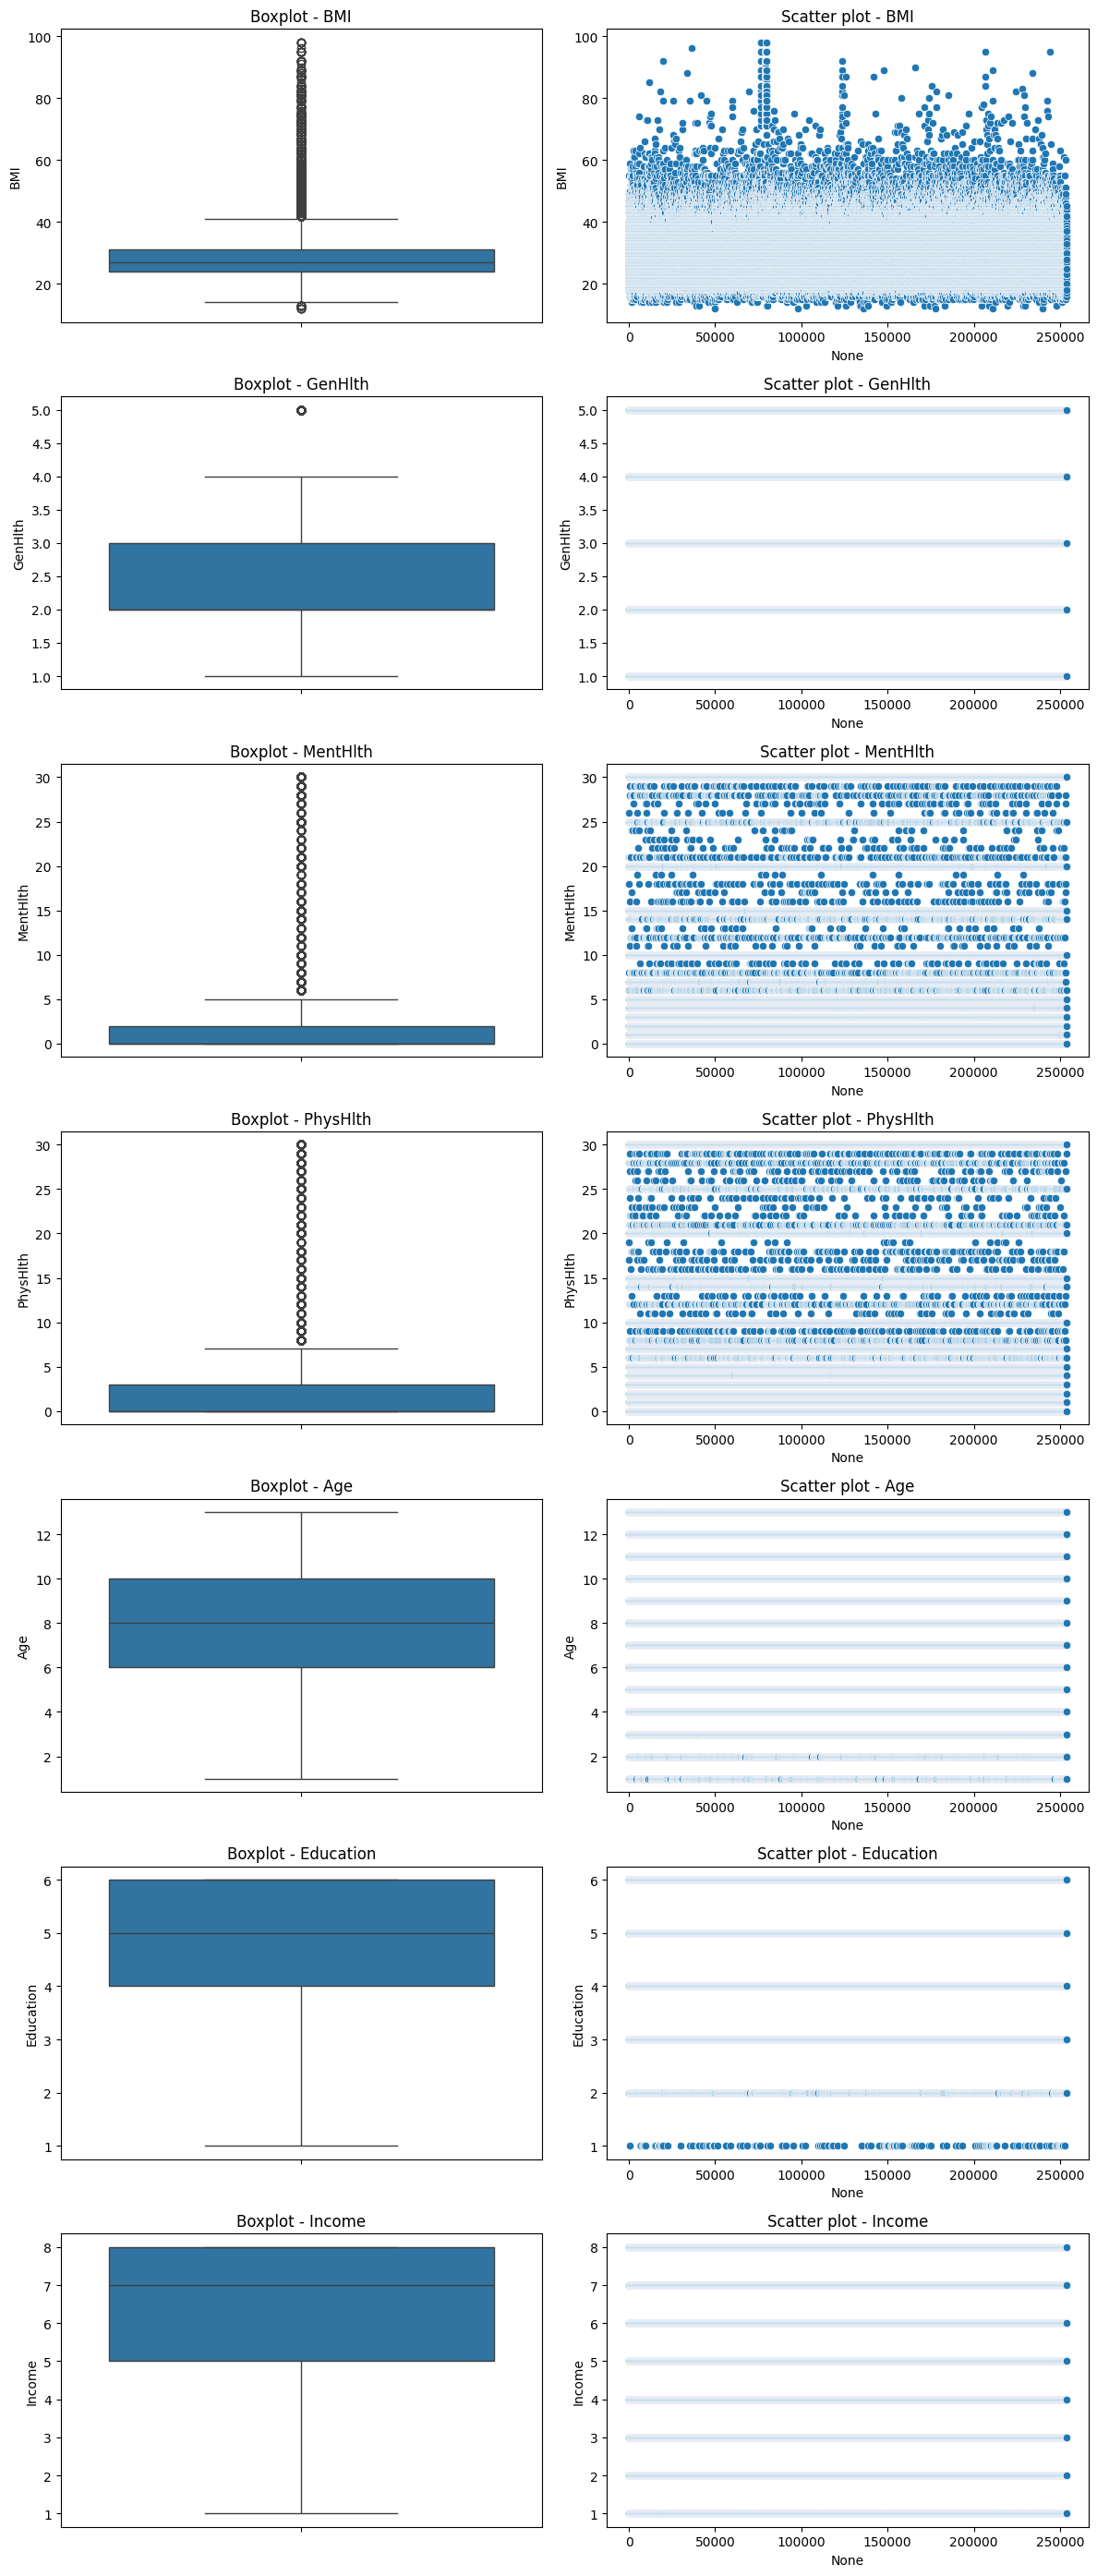

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

def draw_outliers(df):
    columns = [col for col in ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age','Education', 'Income']]
    fig, ax = plt.subplots(len(columns), 2, figsize=(12, 4 * len(columns)))
    for i, column in enumerate(columns):
        sns.boxplot(y=df[column], ax=ax[i, 0])
        ax[i, 0].set_title(f'Boxplot - {column}')
    
        sns.scatterplot(
            x=df.index,
            y=df[column],
            ax=ax[i, 1]
        )
        ax[i, 1].set_title(f'Scatter plot - {column}')
    plt.tight_layout()
    plt.show()

draw_outliers(data)

In [26]:
data.duplicated().sum()

np.int64(24206)

In [28]:
data.drop_duplicates(inplace = True)
data.duplicated().sum()

np.int64(0)

In [29]:
data.shape

(229474, 22)

In [45]:
data["Diabetes_binary"].value_counts()

Diabetes_binary
0    194377
1     35097
Name: count, dtype: int64

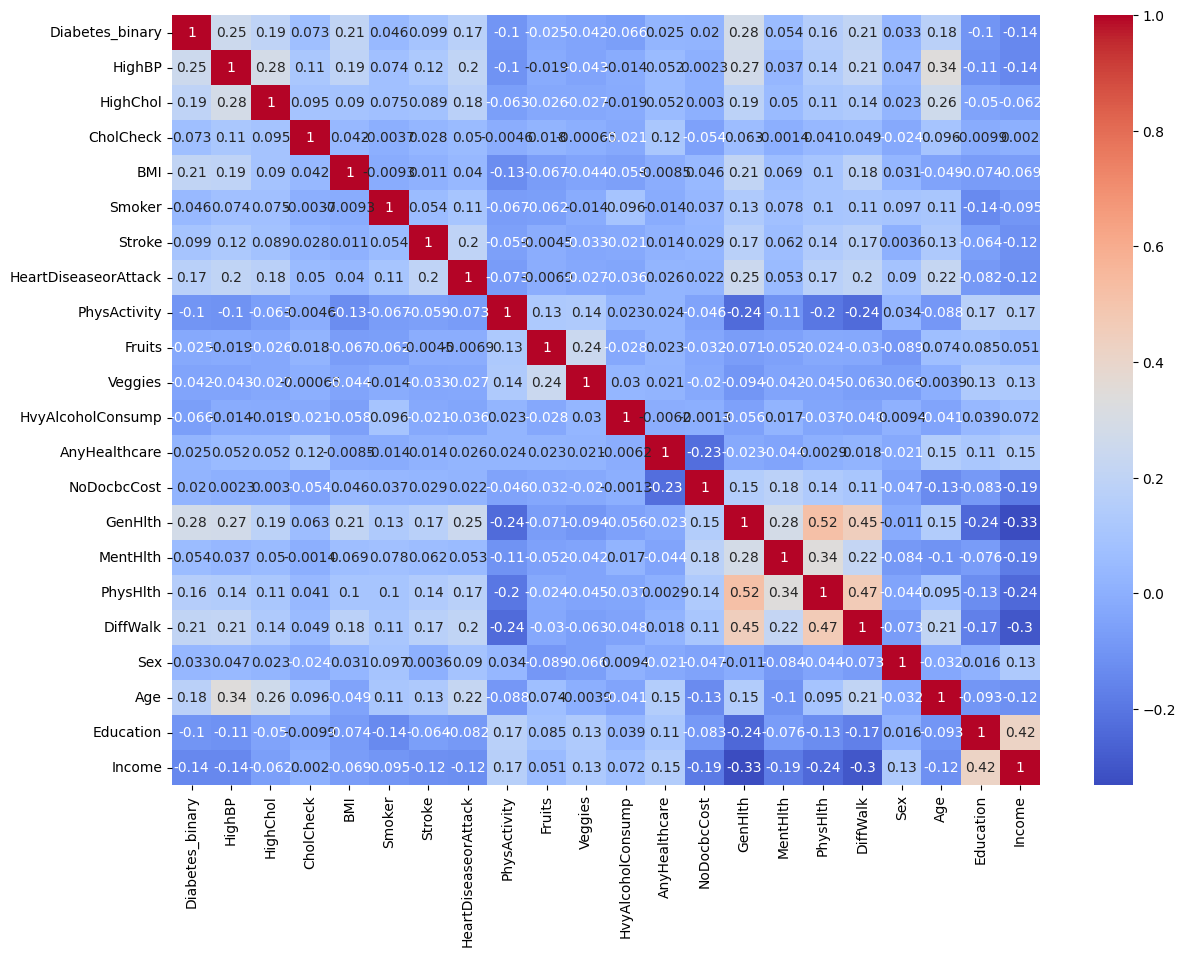

                Variable         VIF
0                  const  109.425291
1        Diabetes_binary    1.182154
2                 HighBP    1.315161
3               HighChol    1.166374
4              CholCheck    1.035970
5                    BMI    1.141796
6                 Smoker    1.076125
7                 Stroke    1.077944
8   HeartDiseaseorAttack    1.170400
9           PhysActivity    1.130550
10                Fruits    1.097950
11               Veggies    1.098136
12     HvyAlcoholConsump    1.027834
13         AnyHealthcare    1.109935
14           NoDocbcCost    1.135686
15               GenHlth    1.741508
16              MentHlth    1.221789
17              PhysHlth    1.594308
18              DiffWalk    1.513943
19                   Sex    1.076736
20                   Age    1.359039
21             Education    1.272148
22                Income    1.431806


In [44]:
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

def draw_heatmap(df):
    num_vars = df.select_dtypes(include=np.number)
    corr = num_vars.corr()
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.show()
    
    X = sm.add_constant(num_vars)
    vif = pd.DataFrame()
    vif['Variable'] = X.columns
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    print(vif)

draw_heatmap(data)

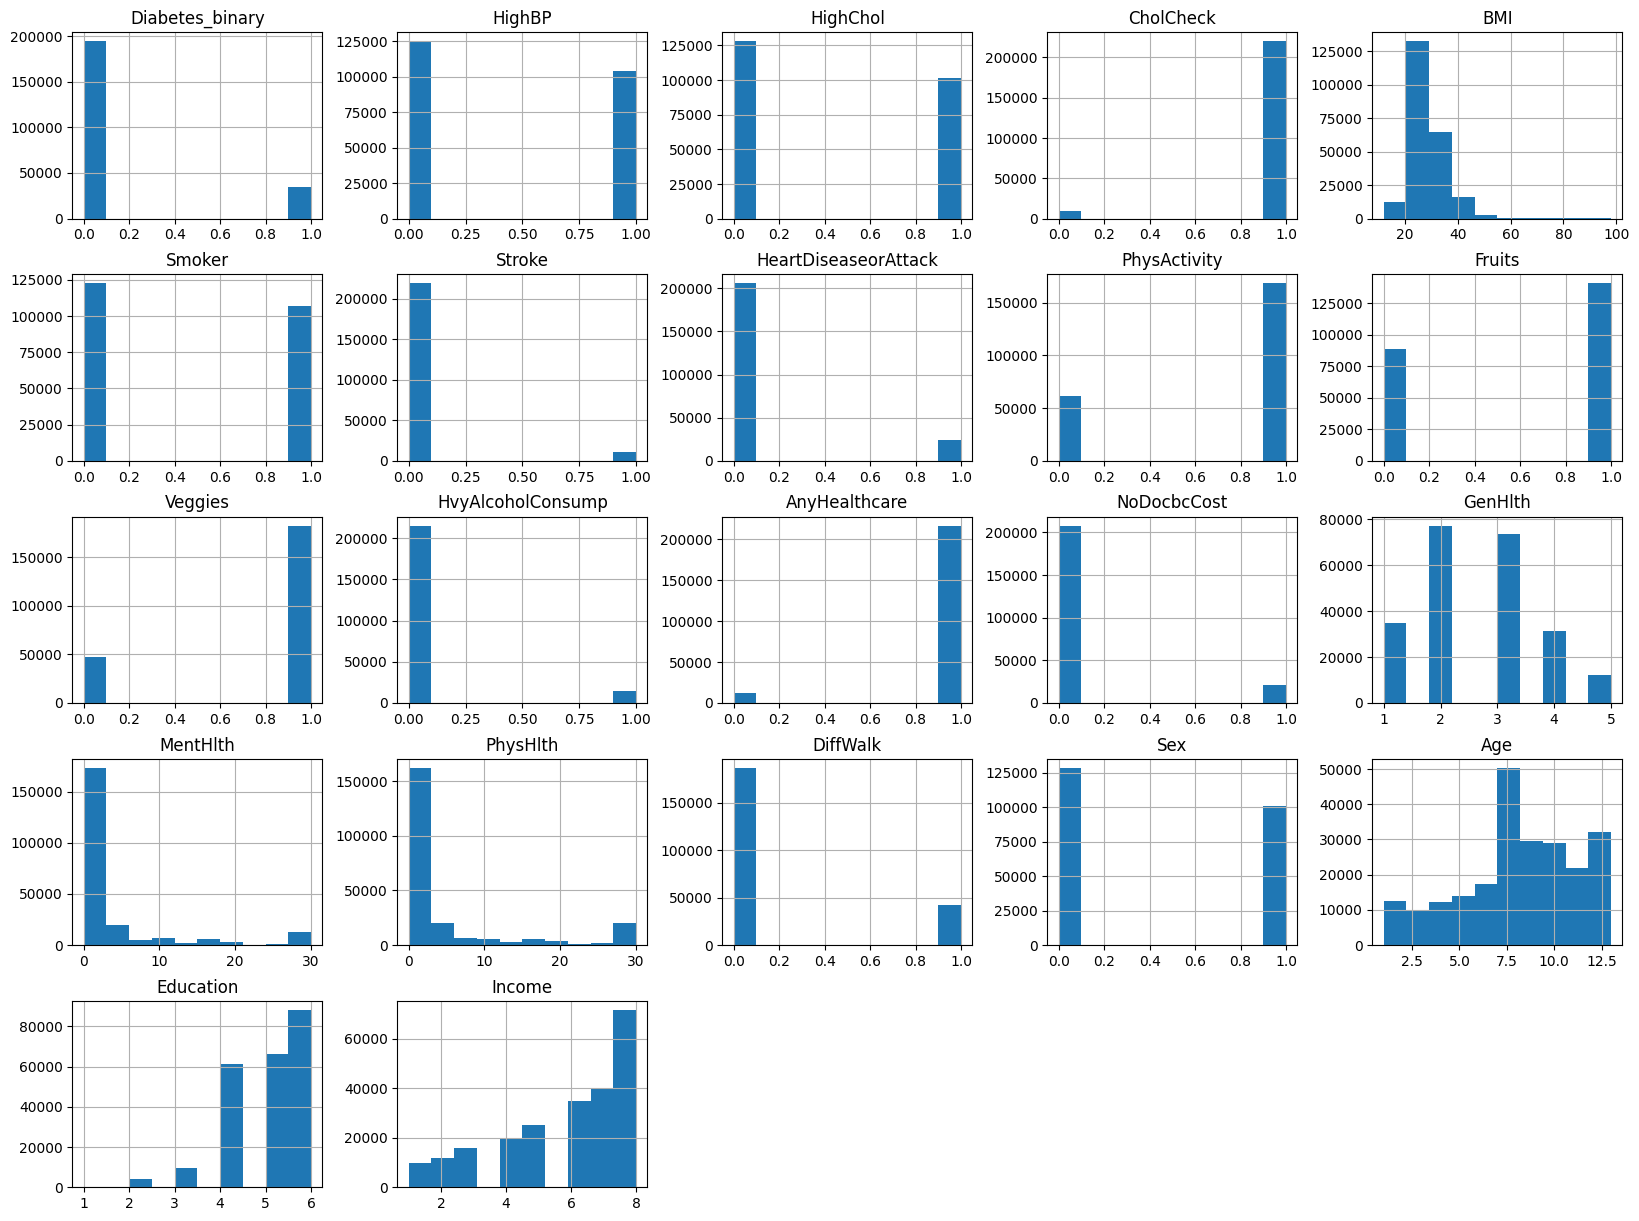

In [32]:
data.hist(figsize=(20,15));

In [41]:
from scipy.stats import mannwhitneyu

columns_to_check = [col for col in data.columns if col != 'Diabetes_binary']
for column in columns_to_check:
    MWU, p = mannwhitneyu(data[column], data['Diabetes_binary'])
    print(f'Column: {column}, MWU: {MWU}, p-value: {p}')

Column: HighBP, MWU: 34264713469.0, p-value: 0.0
Column: HighChol, MWU: 33930255114.0, p-value: 0.0
Column: CholCheck, MWU: 47564567561.0, p-value: 0.0
Column: BMI, MWU: 52658316676.0, p-value: 0.0
Column: Smoker, MWU: 34566357042.0, p-value: 0.0
Column: Stroke, MWU: 23482189157.0, p-value: 0.0
Column: HeartDiseaseorAttack, MWU: 25022992330.0, p-value: 0.0
Column: PhysActivity, MWU: 41602603567.0, p-value: 0.0
Column: Fruits, MWU: 38433452890.0, p-value: 0.0
Column: Veggies, MWU: 43223034218.0, p-value: 0.0
Column: HvyAlcoholConsump, MWU: 23902814999.0, p-value: 0.0
Column: AnyHealthcare, MWU: 47209915494.0, p-value: 0.0
Column: NoDocbcCost, MWU: 24748770900.0, p-value: 0.0
Column: GenHlth, MWU: 52046681257.0, p-value: 0.0
Column: MentHlth, MWU: 32362152499.0, p-value: 0.0
Column: PhysHlth, MWU: 34396713116.5, p-value: 0.0
Column: DiffWalk, MWU: 27192898474.0, p-value: 6.577077779132906e-193
Column: Sex, MWU: 33863019232.0, p-value: 0.0
Column: Age, MWU: 52561606892.5, p-value: 0.0
Col

In [ ]:
balanced_data.to_csv(r'..\zbiory\data_diabetes_processed.csv', header=True, index=False, encoding='utf-8')
print("Zapisano plik.")

In [15]:
import pandas as pd

#data = pd.read_csv(r"..\zbiory\data_diabetes_processed.csv")

class_0 = data[data['Diabetes_binary'] == 0]
class_1 = data[data['Diabetes_binary'] == 1]

class_0_sample = class_0.sample(n=len(class_1), random_state=42)
balanced_data = pd.concat([class_0_sample, class_1])

balanced_data = balanced_data.sample(frac=1, random_state=42)

print(balanced_data['Diabetes_binary'].value_counts())
print(balanced_data.shape)

n = 2500
class_0_sample = class_0.sample(n=n, random_state=42)
class_1_sample = class_1.sample(n=n, random_state=42)

balanced_data = pd.concat([class_0_sample, class_1_sample])
balanced_data = balanced_data.sample(frac=1, random_state=42)

print(balanced_data['Diabetes_binary'].value_counts())
print(balanced_data.shape)

balanced_data.to_csv(r'..\zbiory\data_diabetes_cropped.csv', header=True, index=False, encoding='utf-8')
print("Zapisano plik.")

Diabetes_binary
0    35097
1    35097
Name: count, dtype: int64
(70194, 22)
Diabetes_binary
0    2500
1    2500
Name: count, dtype: int64
(5000, 22)
Zapisano plik.


### Podział zbioru na dane testowe i treningowe

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

data = pd.read_csv(r"..\zbiory_przerobione\data_diabetes_cropped.csv")
print(np.shape(data))

y = data['Diabetes_binary']
X = data.drop(columns=['Diabetes_binary'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(y_train.value_counts())

for column in X_train.columns:
    standardScaler = StandardScaler().fit(X_train[[column]])
    X_train[column] = standardScaler.transform(X_train[[column]])
    X_test[column] = standardScaler.transform(X_test[[column]])

#---------- ustawienie badanego id oraz klas predykcyjnych
class_names = ["'No'", "'Yes'"]
sample_pos = 9
x_sample = X_train.iloc[sample_pos]
true_class = y_train.iloc[sample_pos]
print(f"Klasa, do której należy probka o wskazanej pozycji ({sample_pos}): {true_class}\n{x_sample}")

X_train.head()

(5000, 22)
Diabetes_binary
1    2000
0    2000
Name: count, dtype: int64
Klasa, do której należy probka o wskazanej pozycji (9): 0
HighBP                 -1.190344
HighChol                0.910948
CholCheck               0.168160
BMI                    -0.431874
Smoker                 -0.968011
Stroke                 -0.269047
HeartDiseaseorAttack   -0.414716
PhysActivity            0.695075
Fruits                  0.826313
Veggies                 0.514414
HvyAlcoholConsump      -0.223929
AnyHealthcare           0.238334
NoDocbcCost            -0.347056
GenHlth                -0.818094
MentHlth               -0.004804
PhysHlth               -0.602417
DiffWalk               -0.619744
Sex                     1.079664
Age                    -0.932763
Education               1.122655
Income                  0.682772
Name: 2645, dtype: float64


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
2864,-1.190344,-1.097758,0.16816,-0.296945,1.033046,-0.269047,-0.414716,0.695075,0.826313,0.514414,...,0.238334,-0.347056,0.088381,-0.482260,2.327866,-0.619744,1.079664,1.145046,1.122655,1.145197
649,0.840093,0.910948,0.16816,0.242771,-0.968011,-0.269047,-0.414716,-1.438693,-1.210195,0.514414,...,0.238334,-0.347056,-0.818094,-0.004804,-0.407065,-0.619744,-0.926214,0.452443,0.153596,0.682772
1144,0.840093,0.910948,0.16816,-0.971590,-0.968011,-0.269047,-0.414716,0.695075,-1.210195,0.514414,...,0.238334,2.881376,0.994856,3.098656,2.327866,-0.619744,1.079664,-0.240160,-0.815463,0.682772
3208,0.840093,0.910948,0.16816,-0.971590,-0.968011,-0.269047,-0.414716,0.695075,0.826313,0.514414,...,0.238334,-0.347056,0.088381,-0.004804,0.765048,-0.619744,-0.926214,-1.625367,1.122655,1.145197
3862,-1.190344,-1.097758,0.16816,-1.106519,-0.968011,-0.269047,-0.414716,0.695075,-1.210195,0.514414,...,0.238334,-0.347056,-1.724569,-0.482260,-0.602417,-0.619744,-0.926214,-1.625367,1.122655,0.220346


### Random Forest - nauka modelu

ROC AUC: 0.791244
Report:
              precision    recall  f1-score   support

           0       0.73      0.70      0.71       500
           1       0.71      0.73      0.72       500

    accuracy                           0.72      1000
   macro avg       0.72      0.72      0.72      1000
weighted avg       0.72      0.72      0.72      1000



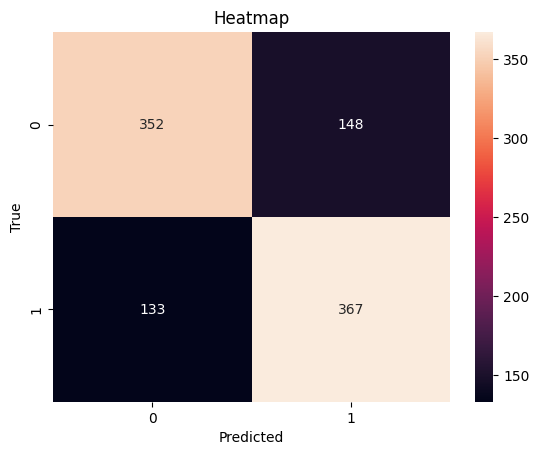

Przewidywanie dla wskazanego id:  [[0.87 0.13]]


In [3]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model = train_model(random_forest_model, X_train, y_train, X_test, y_test, sample_pos)

### Random Forest - LIME

C:\Users\savan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


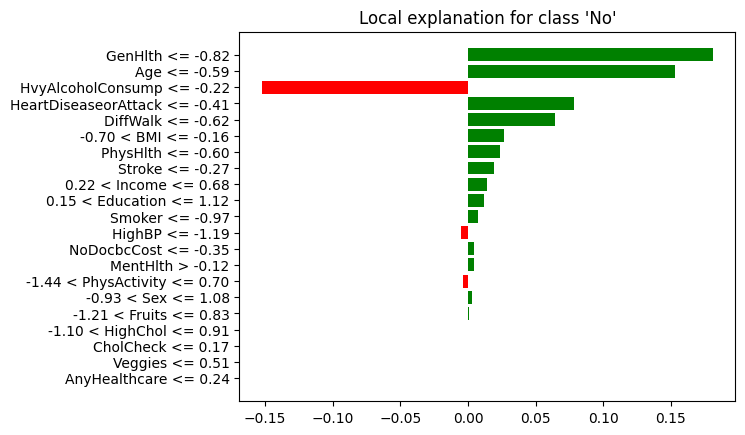

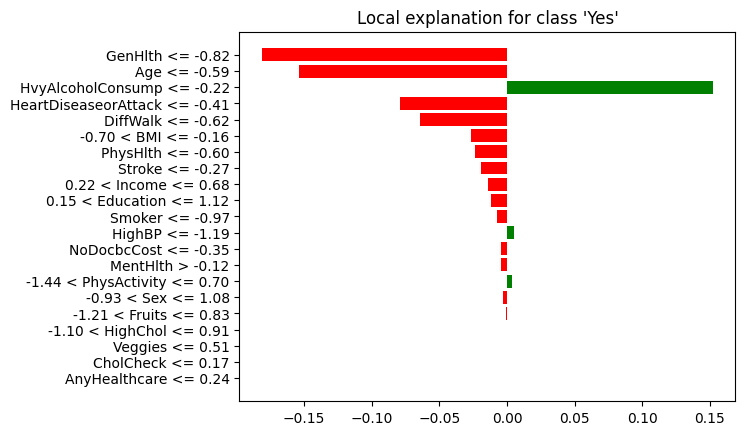




(2, 21, 2)


<Figure size 640x480 with 0 Axes>

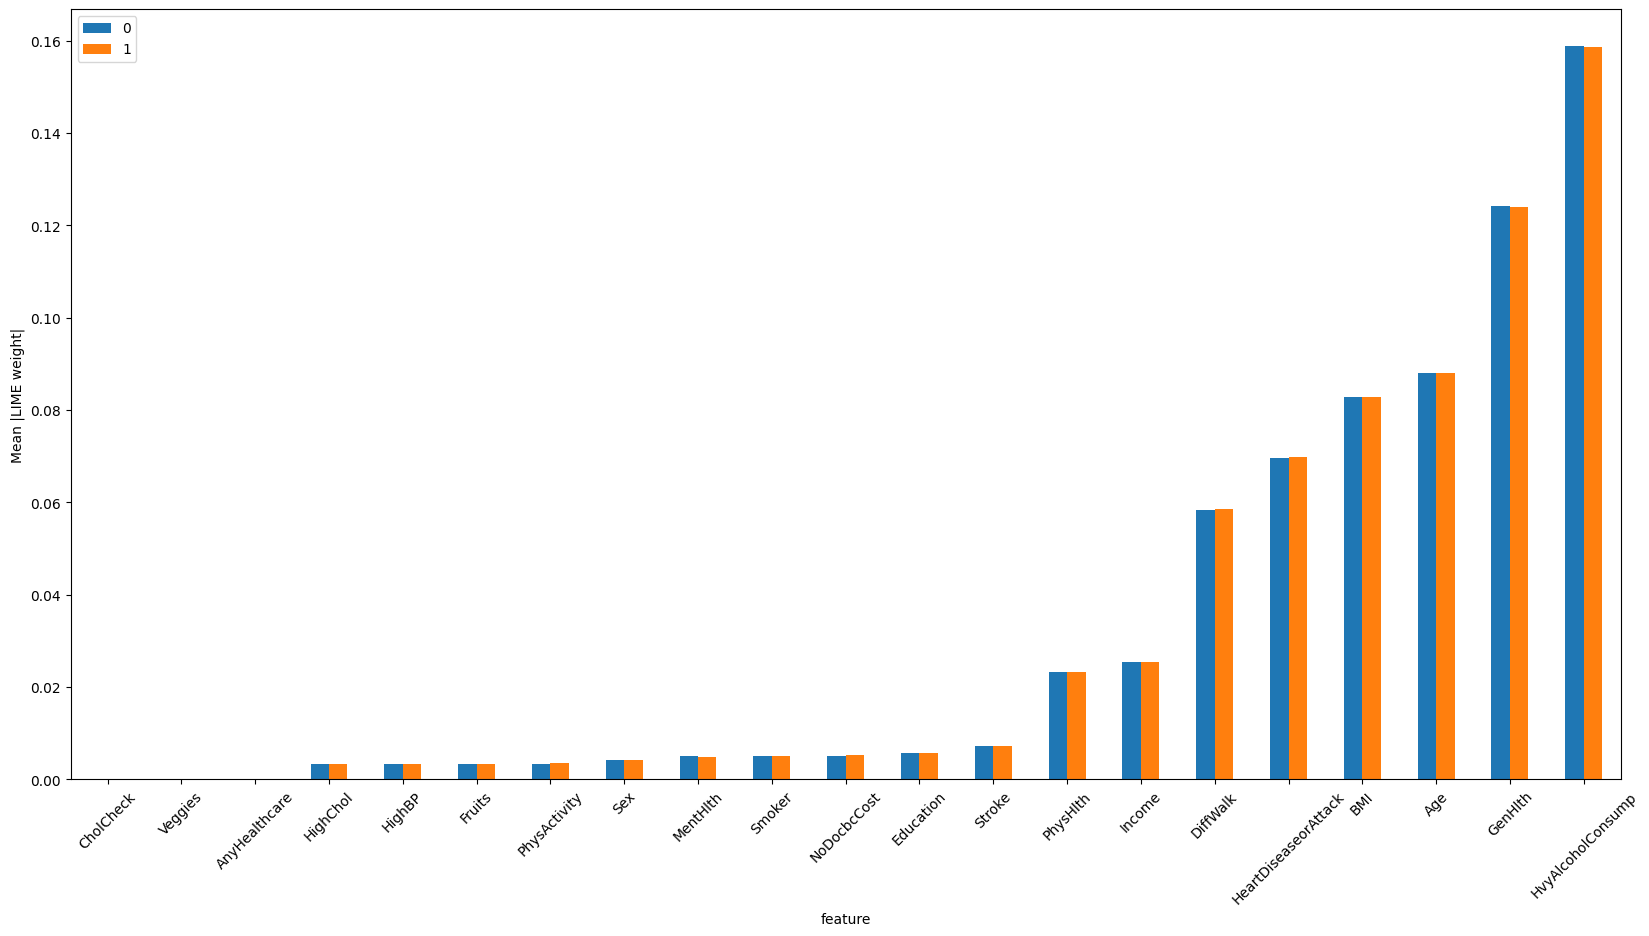

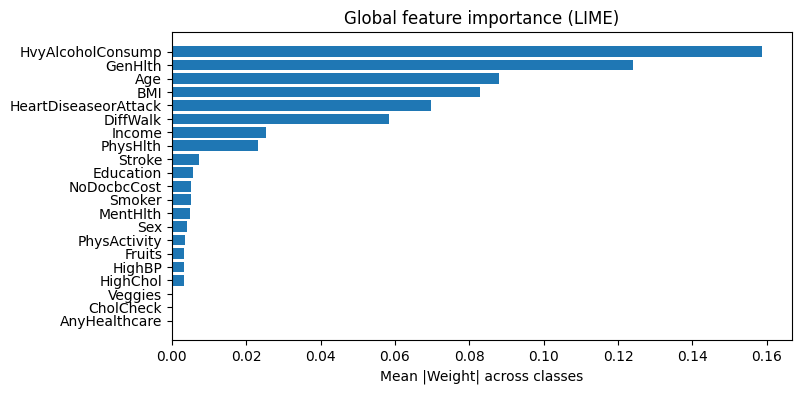

In [4]:
lime(random_forest_model, X_train, class_names, sample_pos)

### Random Forest - SHAP

(4000, 21, 2)

Local explanation for class 0


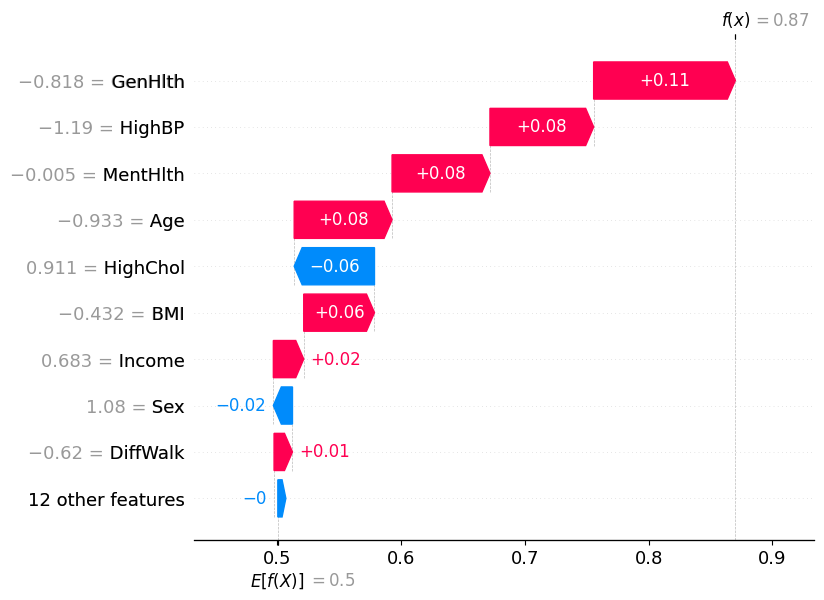


Local explanation for class 1


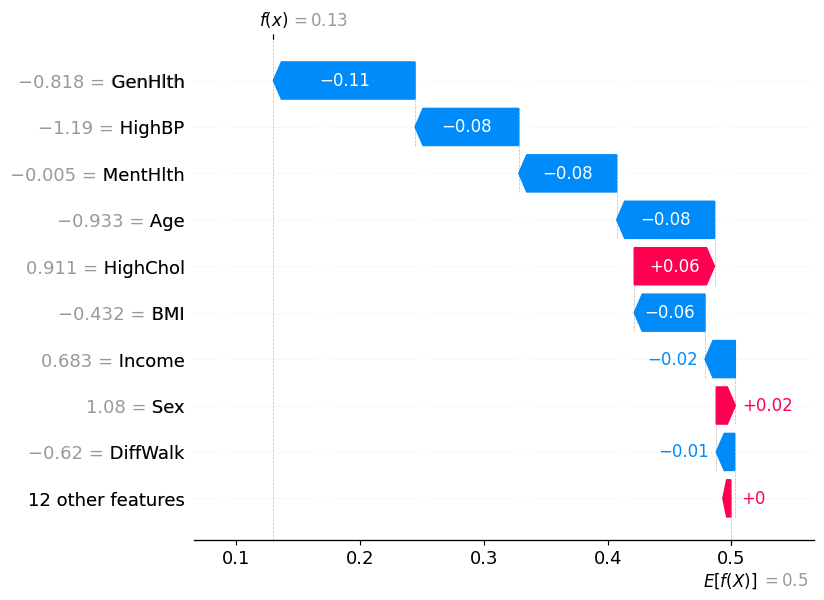

(4000, 21)


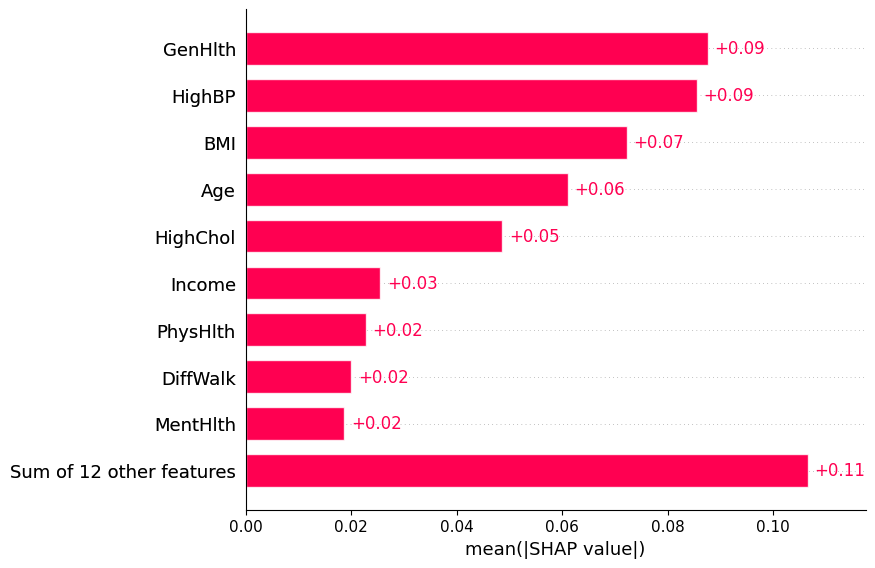

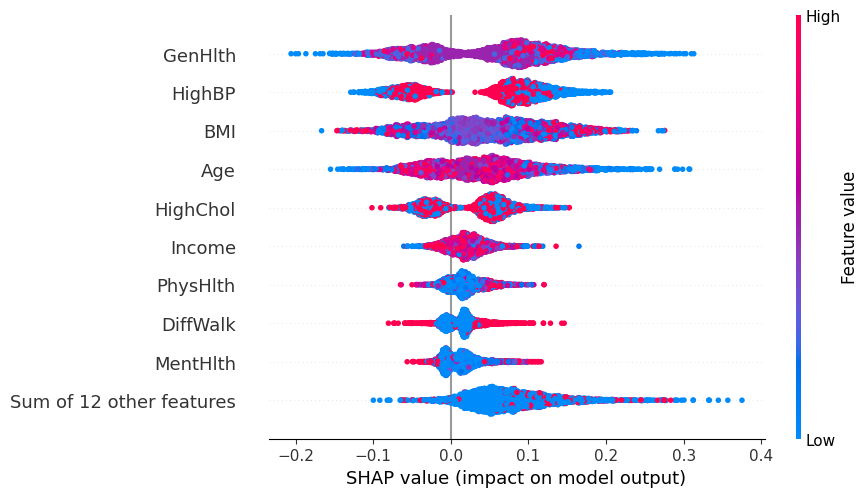

In [7]:
binary_shap(random_forest_model, X_train, class_names, sample_pos)

### Random Forest - PFI

GenHlth 0.146 +/- 0.005
BMI     0.143 +/- 0.004
HighBP  0.115 +/- 0.003
Age     0.109 +/- 0.003
HighChol0.072 +/- 0.003
Income  0.059 +/- 0.002
PhysHlth0.051 +/- 0.002
MentHlth0.037 +/- 0.002
Education0.031 +/- 0.002
Sex     0.027 +/- 0.001
DiffWalk0.027 +/- 0.001
HeartDiseaseorAttack0.024 +/- 0.002
Smoker  0.023 +/- 0.001
Fruits  0.017 +/- 0.001
PhysActivity0.014 +/- 0.001
Veggies 0.009 +/- 0.001
HvyAlcoholConsump0.008 +/- 0.001
Stroke  0.006 +/- 0.000
NoDocbcCost0.004 +/- 0.000
CholCheck0.004 +/- 0.001
AnyHealthcare0.003 +/- 0.000


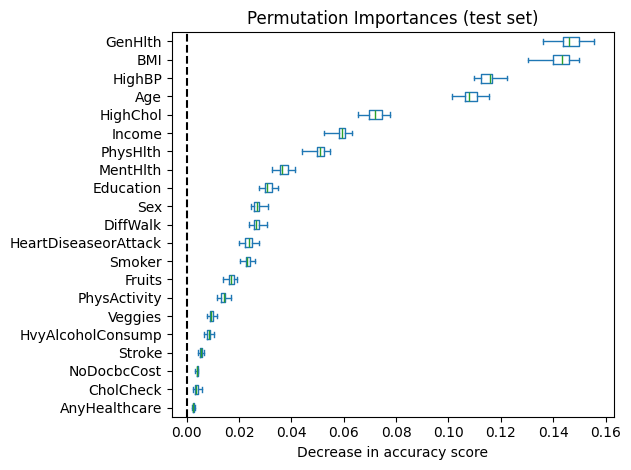

In [20]:
pfi(random_forest_model, X_train, y_train)

### XGBoost - nauka modelu

ROC AUC: 0.771276
Report:
              precision    recall  f1-score   support

           0       0.70      0.70      0.70       500
           1       0.70      0.69      0.70       500

    accuracy                           0.70      1000
   macro avg       0.70      0.70      0.70      1000
weighted avg       0.70      0.70      0.70      1000



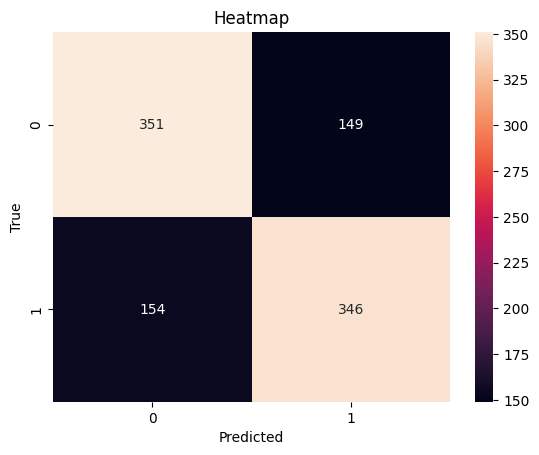

Przewidywanie dla wskazanego id:  [[0.9792 0.0208]]


In [5]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(random_state=42, subsample=0.8, colsample_bytree=0.8)
xgb_model = train_model(xgb_model, X_train, y_train, X_test, y_test, sample_pos)

### XGBoost - LIME

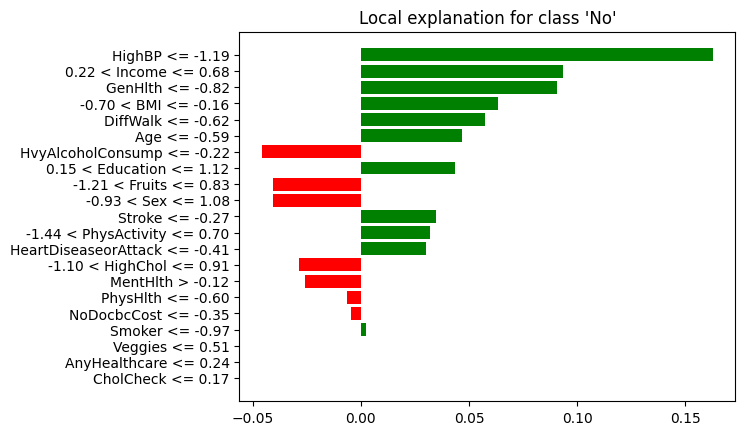

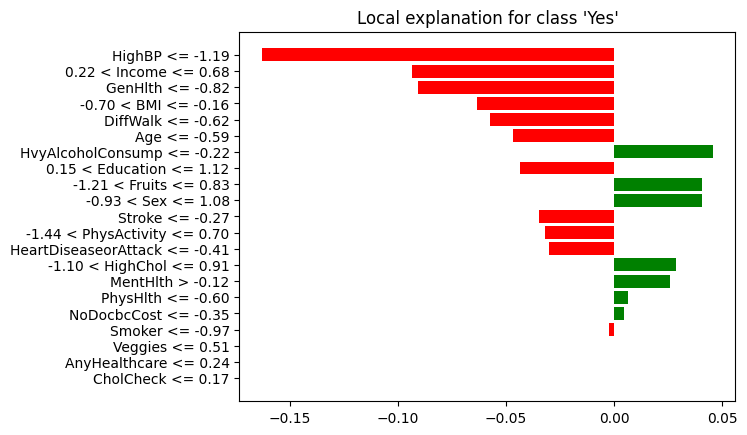




(2, 21, 2)


<Figure size 640x480 with 0 Axes>

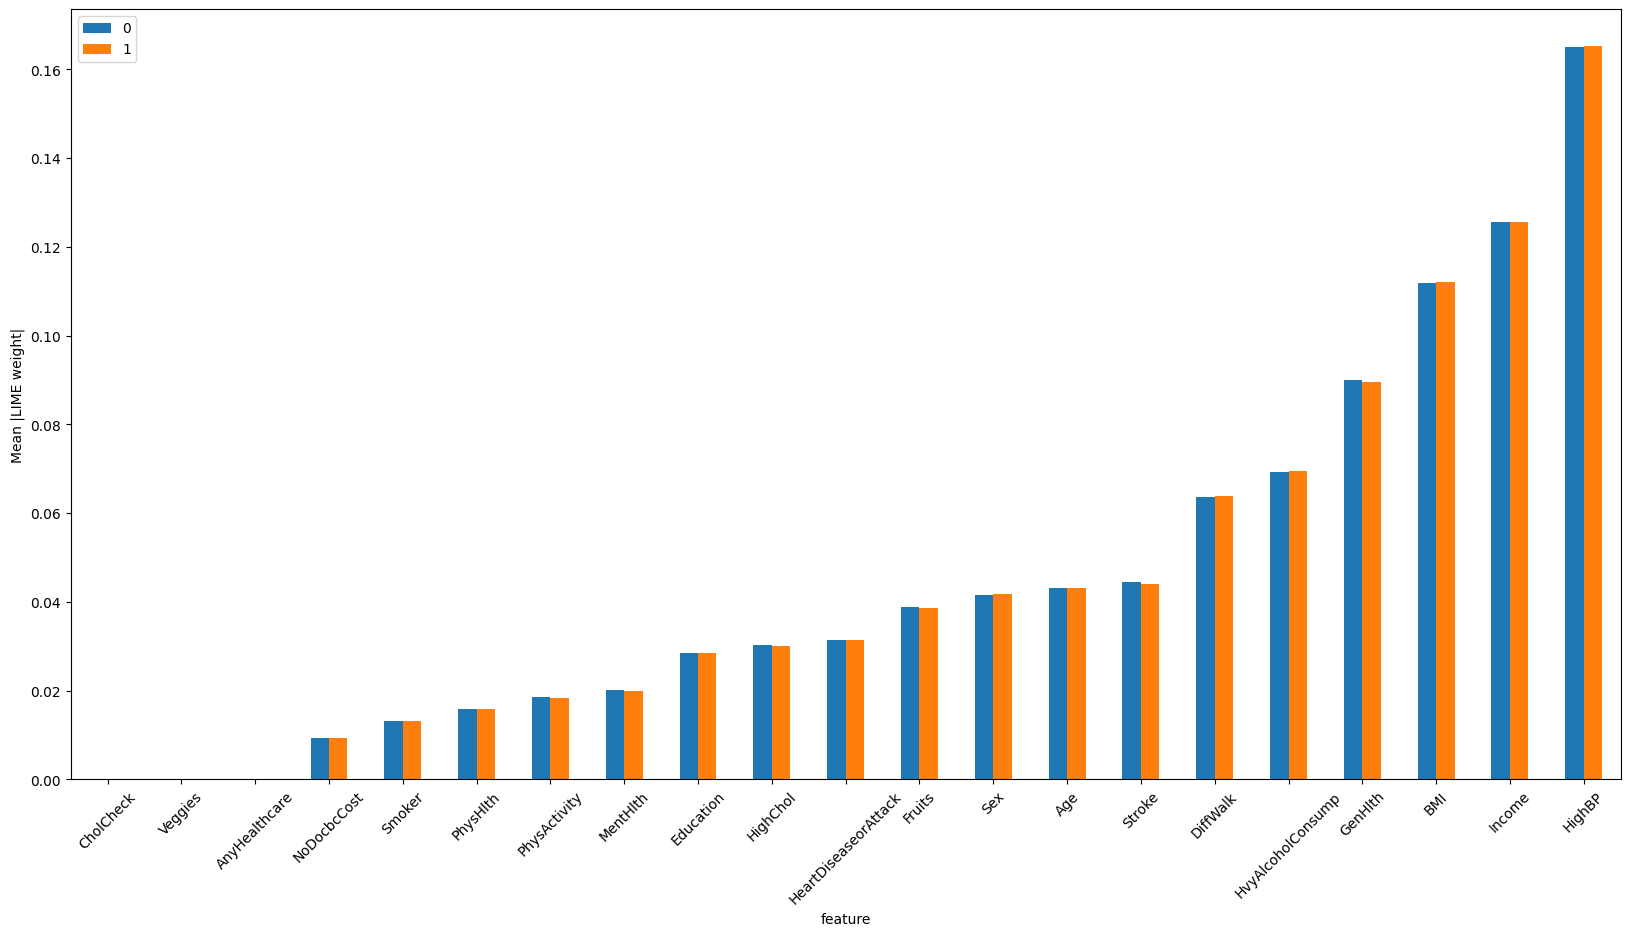

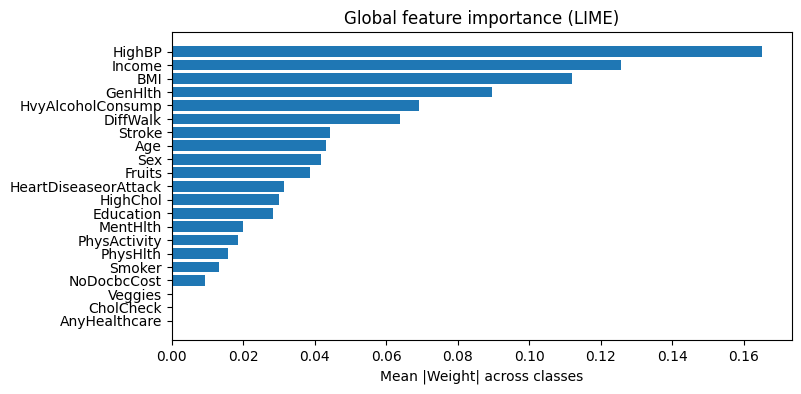

In [6]:
lime(xgb_model, X_train, class_names, sample_pos)

### XGBoost - SHAP

(4000, 21)

Binary classification


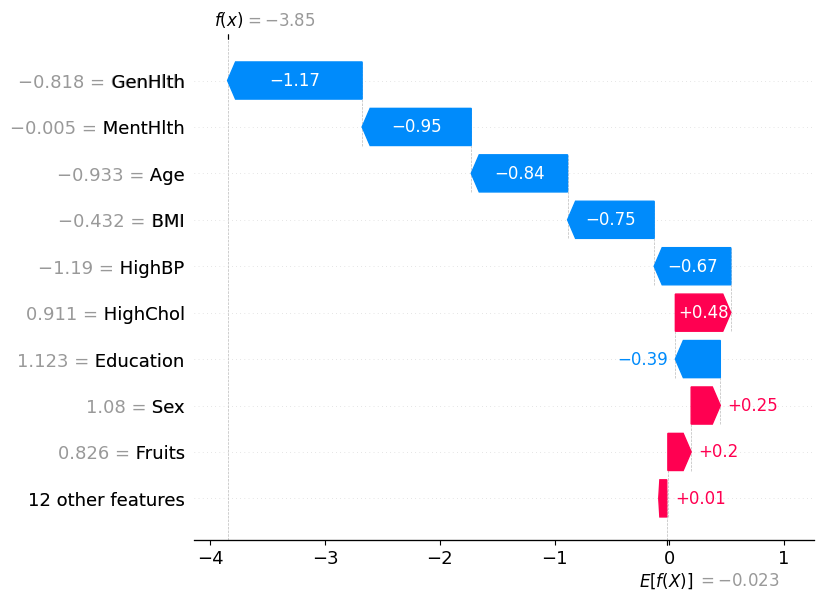

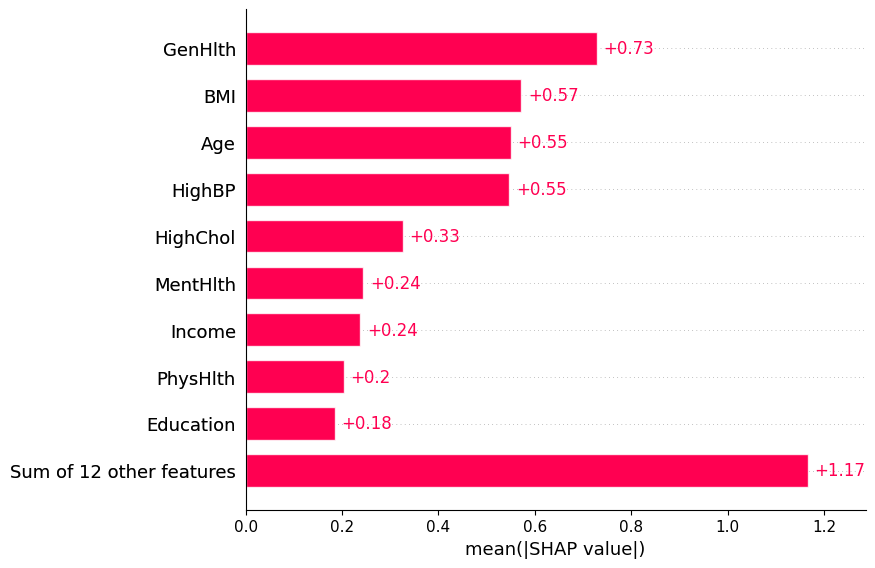

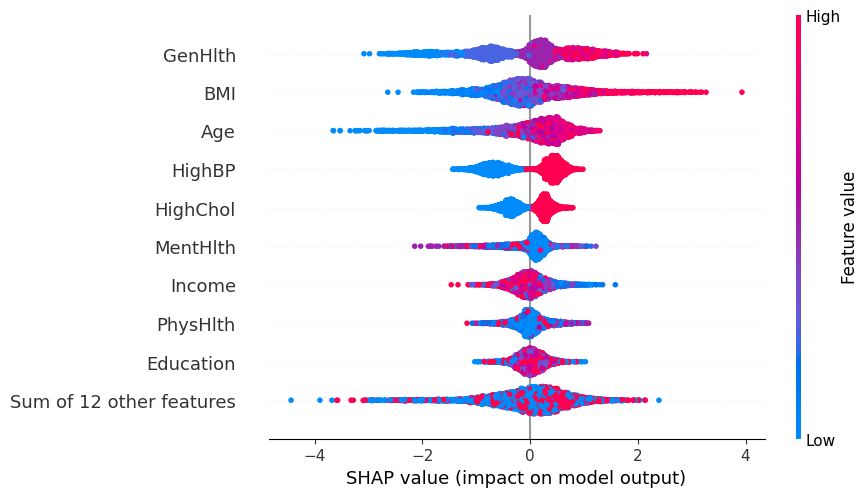

In [29]:
binary_shap(xgb_model, X_train, class_names, sample_pos)

### XGBoost - PFI

BMI     0.149 +/- 0.004
Age     0.128 +/- 0.004
GenHlth 0.126 +/- 0.003
Income  0.085 +/- 0.003
PhysHlth0.063 +/- 0.004
Education0.055 +/- 0.002
MentHlth0.055 +/- 0.002
HighBP  0.049 +/- 0.003
HighChol0.034 +/- 0.002
Smoker  0.028 +/- 0.002
Sex     0.025 +/- 0.002
Fruits  0.024 +/- 0.002
PhysActivity0.023 +/- 0.002
DiffWalk0.019 +/- 0.002
Veggies 0.019 +/- 0.002
HeartDiseaseorAttack0.017 +/- 0.002
HvyAlcoholConsump0.015 +/- 0.002
CholCheck0.010 +/- 0.001
NoDocbcCost0.009 +/- 0.001
Stroke  0.008 +/- 0.001
AnyHealthcare0.004 +/- 0.001


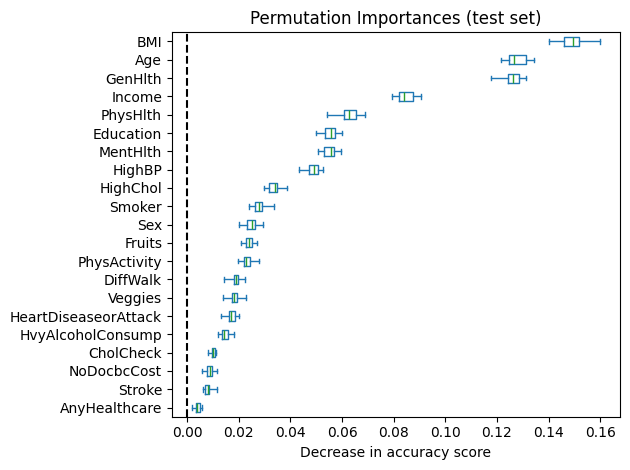

In [5]:
pfi(xgb_model, X_train, y_train)

### Sieć neuronowa - nauka modelu

In [22]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.datasets import make_classification

activations = ["relu", "tanh", "logistic"]
optimizers  = ["adam", "sgd"]
architectures = [
    [16, 16],
    [32, 32],
    [64, 64],
    [32, 64, 32],
    [64, 64, 64],
    [64, 128, 64],
    [64, 128, 128],
    [128, 128, 64],
    [128, 128, 128],
    [64, 128, 128, 64]
]

param_grid = {'activation': activations, 'early_stopping': [True], 'hidden_layer_sizes': architectures, 'solver': optimizers}
mlp_classifier = MLPClassifier(random_state=42)
mlp_classifier_cv = GridSearchCV(mlp_classifier, param_grid, cv=5, n_jobs=2)

mlp_classifier_cv.fit(X_train, y_train)

print("MLPClassifier parameters for best model: {}".format(mlp_classifier_cv.best_params_))
print("Best score is {}".format(mlp_classifier_cv.best_score_))

MLPClassifier parameters for best model: {'activation': 'tanh', 'early_stopping': True, 'hidden_layer_sizes': [64, 64], 'solver': 'adam'}
Best score is 0.737


ROC AUC: 0.801832
Report:
              precision    recall  f1-score   support

           0       0.73      0.70      0.71       500
           1       0.71      0.74      0.72       500

    accuracy                           0.72      1000
   macro avg       0.72      0.72      0.72      1000
weighted avg       0.72      0.72      0.72      1000



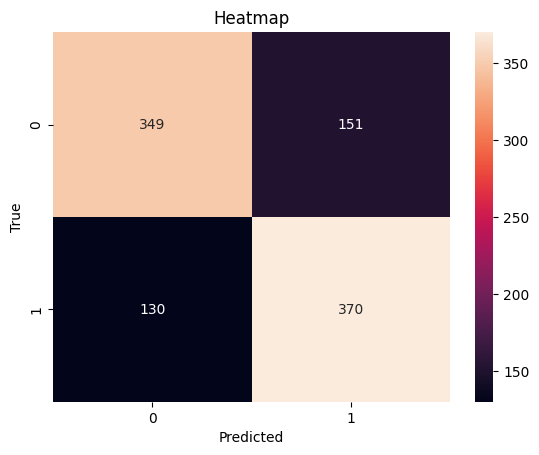

Przewidywanie dla wskazanego id:  [[0.802 0.198]]


In [7]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

dnn_model = MLPClassifier(activation='tanh', early_stopping = True, hidden_layer_sizes=(64, 64), solver='adam', random_state=42)
dnn_model = train_model(dnn_model, X_train, y_train, X_test, y_test, sample_pos)

### Sieć neuronowa - LIME

C:\Users\savan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


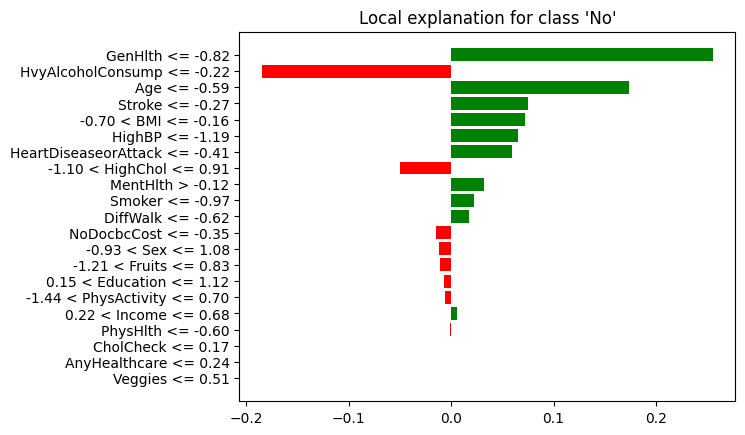

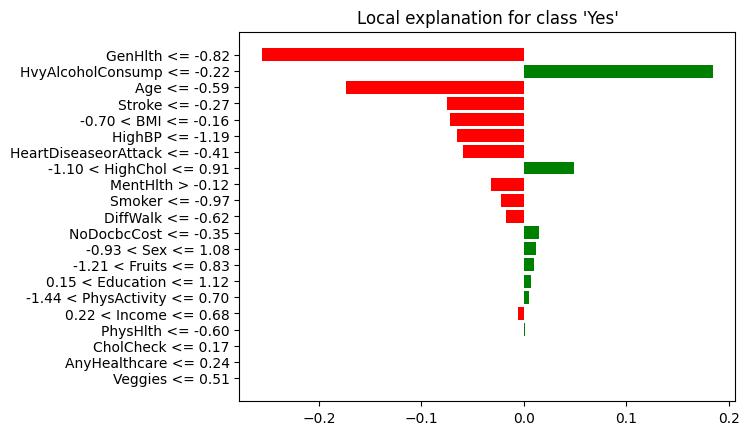




(2, 21, 2)


<Figure size 640x480 with 0 Axes>

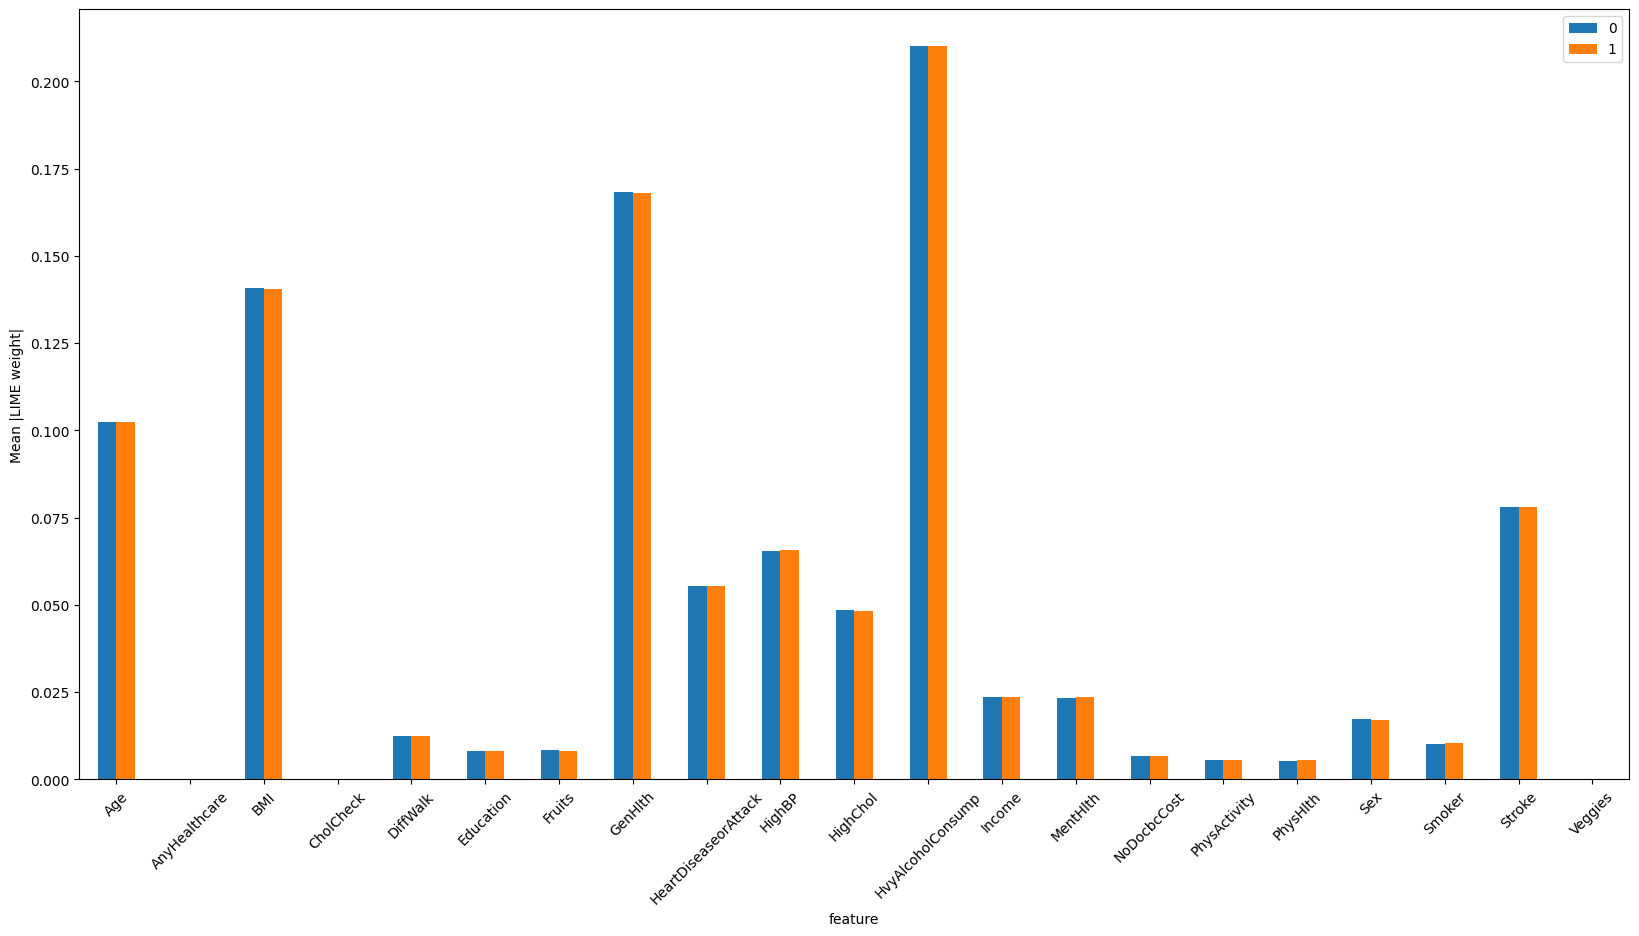

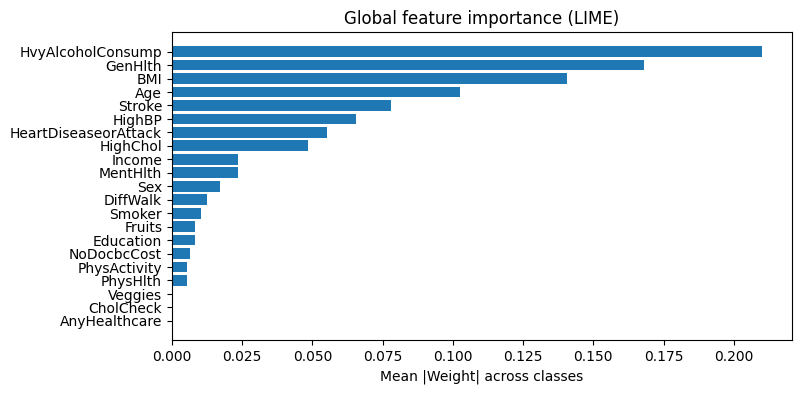

In [8]:
lime(dnn_model, X_train, class_names, sample_pos)

### Sieć neuronowa - SHAP

PermutationExplainer explainer: 4001it [04:03, 16.21it/s]                                                              


(4000, 21, 2)

Local explanation for class 0


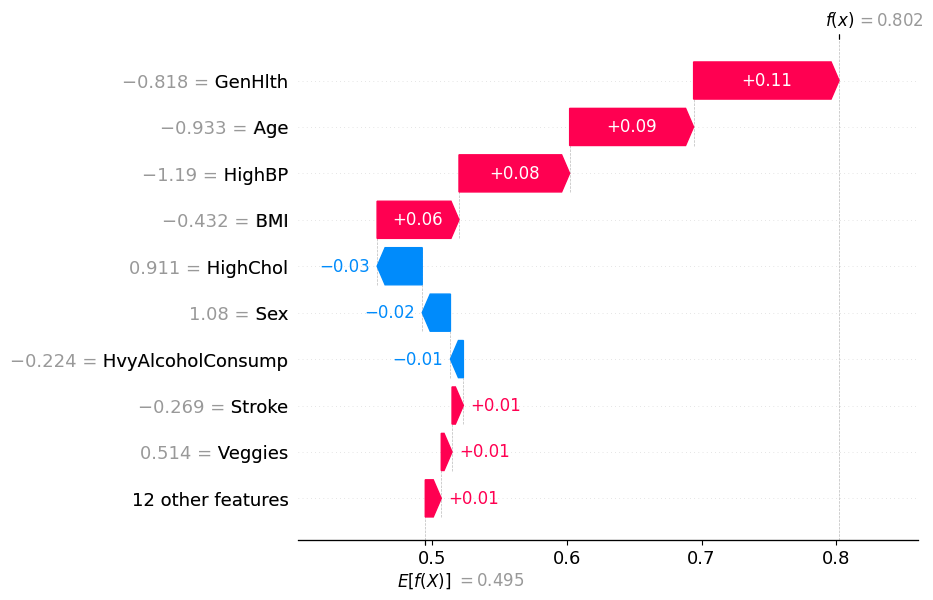


Local explanation for class 1


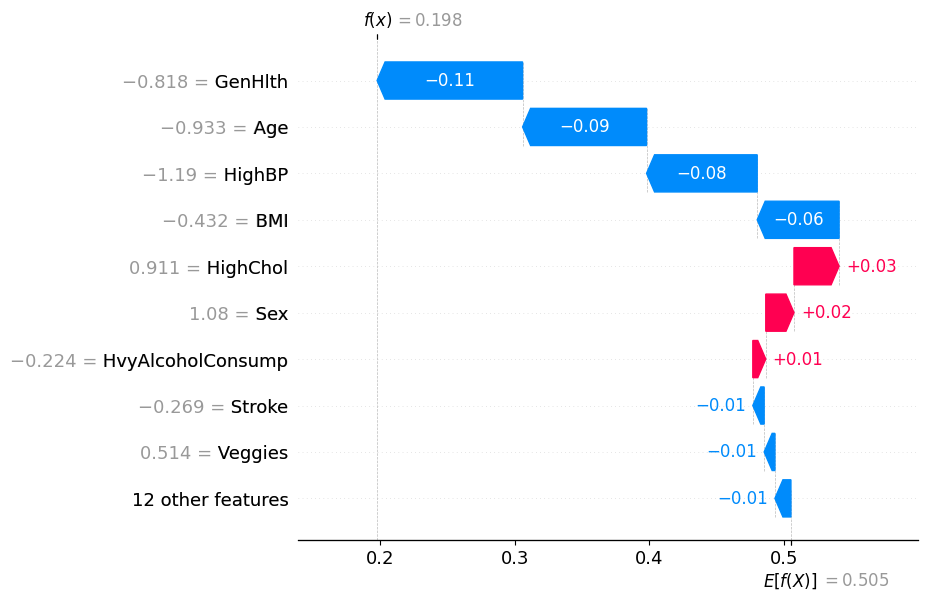

(4000, 21)


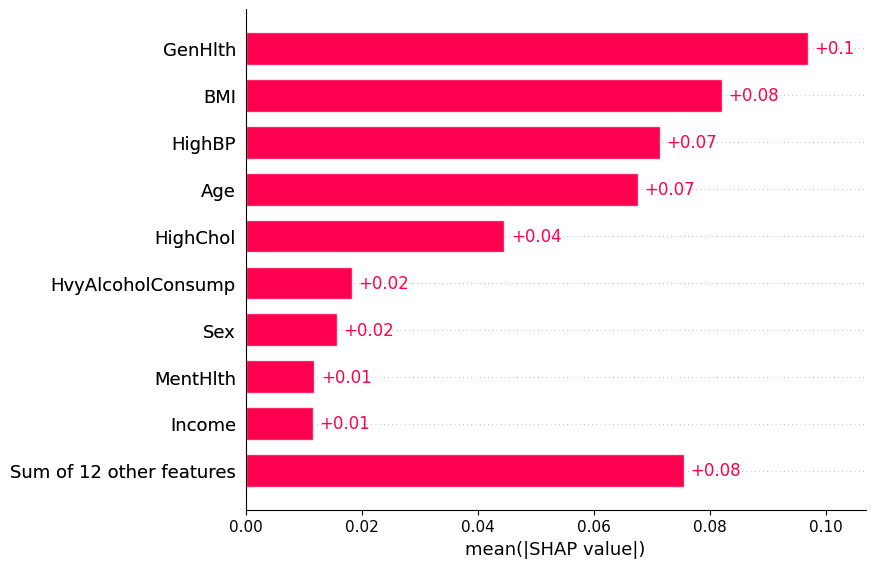

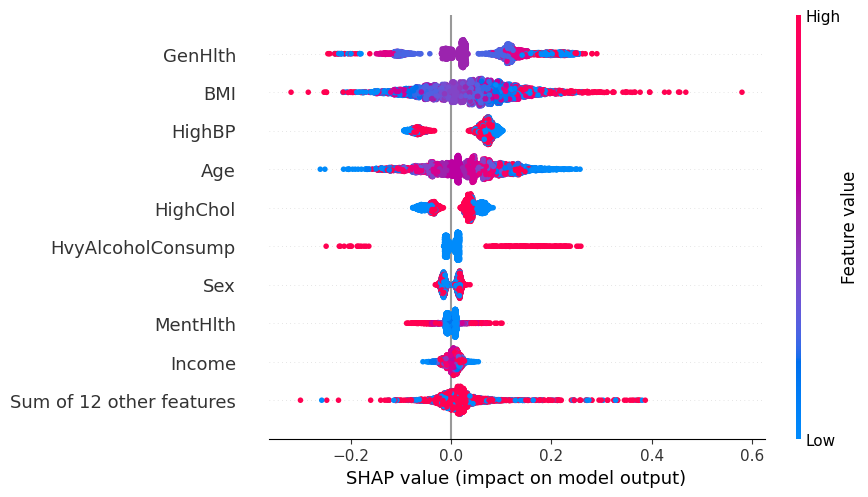

In [46]:
binary_shap(dnn_model, X_train, class_names, sample_pos)

### Sieć neuronowa - PFI

GenHlth 0.055 +/- 0.006
BMI     0.041 +/- 0.004
Age     0.023 +/- 0.003
HighBP  0.021 +/- 0.003
HvyAlcoholConsump0.007 +/- 0.002
CholCheck0.006 +/- 0.002


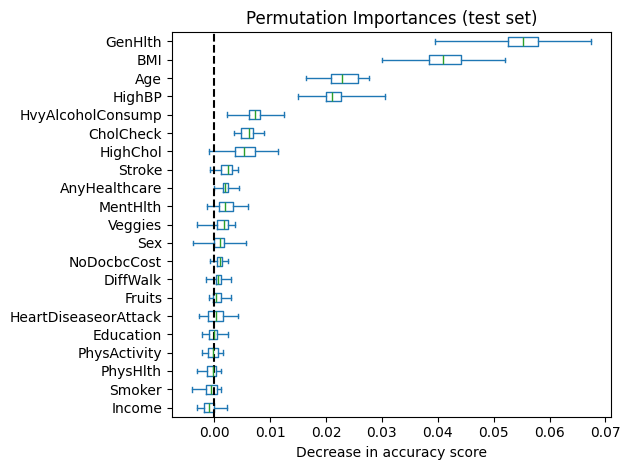

In [29]:
pfi(dnn_model, X_train, y_train)